In [27]:
!pip3 install dotenv

  Using cached dotenv-0.9.9-py2.py3-none-any.whl.metadata (279 bytes)
Using cached dotenv-0.9.9-py2.py3-none-any.whl (1.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [dotenv]


### 1. Import Dependencies

In [30]:
import pandas as pd
import numpy as np
import openai, groq
import seaborn as sns
from enum import Enum
from pydantic import BaseModel
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
client = OpenAI()

### 2. Basic Information

In [8]:
df = pd.read_csv("/Users/hevindutilakasena/Bootcamp ZuuCrew/EDA/data/raw/CEHHbInToW.csv")

In [10]:
df.head()

,RowNumber,CustomerId,Firstname,Lastname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Grace,Williams,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,2,15647311,David,Jones,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Hank,Williams,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Eva,Taylor,699,France,Female,NaN,1,0.00,2,0,0,93826.63,0
4,5,15737888,Grace,Miller,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [12]:
df.shape

(10000, 15)

In [14]:
# get null values
df.isnull().sum()

RowNumber            0
CustomerId           0
Firstname            7
Lastname             6
CreditScore          0
Geography            0
Gender             108
Age                600
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

### 3. Handling Missing Values

In [15]:
df_copy = df.copy()
df_copy.head()

,RowNumber,CustomerId,Firstname,Lastname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Grace,Williams,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,2,15647311,David,Jones,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Hank,Williams,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Eva,Taylor,699,France,Female,NaN,1,0.00,2,0,0,93826.63,0
4,5,15737888,Grace,Miller,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


#### 3.1 Imputation

<Axes: xlabel='Age', ylabel='Count'>

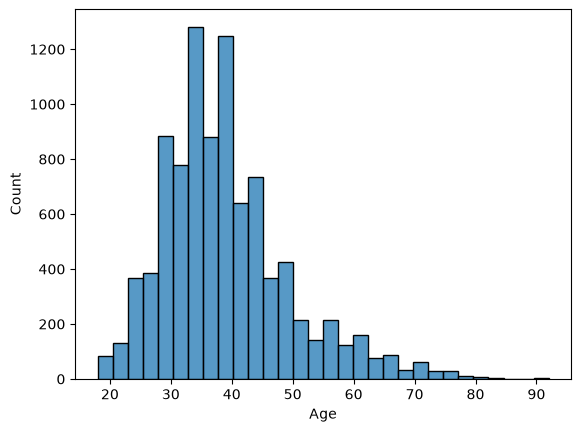

In [20]:
sns.histplot(df['Age'], bins=30)

In [21]:
mean = df['Age'].mean()
median = df['Age'].median()

mean = round(mean, 2)

print(f"Mean: {mean} \nMedian: {median}")

Mean: 38.91 
Median: 37.0


In [22]:
df_impute = df.copy()

In [23]:
df_impute.loc[:, 'Age'] = df_impute['Age'].fillna(mean)
df_impute.head()

,RowNumber,CustomerId,Firstname,Lastname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Grace,Williams,619,France,Female,42.00,2,0.00,1,1,1,101348.88,1
1,2,15647311,David,Jones,608,Spain,Female,41.00,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Hank,Williams,502,France,Female,42.00,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Eva,Taylor,699,France,Female,38.91,1,0.00,2,0,0,93826.63,0
4,5,15737888,Grace,Miller,850,Spain,Female,43.00,2,125510.82,1,1,1,79084.10,0


In [24]:
df_impute.isnull().sum()

RowNumber            0
CustomerId           0
Firstname            7
Lastname             6
CreditScore          0
Geography            0
Gender             108
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

##### Gender 

In [31]:
class Gender(str, Enum):
    MALE = "Male"
    FEMALE = "Female"

class GenderPredication(BaseModel):
    firstname: str
    lastname: str
    pred_gender: Gender

def predict_gender(firstname: str, lastname: str):
    prompt = f"""
            What is the most likely gender (Male or Female) for someone with the first name '{firstname}'
            and last name '{lastname}' ?

            Your response only consists of one word: Male or Female
    """

    response = client.chat.completions.create(
        model = "gpt-4o",
        messages = [
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    predicted_gender = response.choices[0].message.content.strip()
    return predicted_gender


In [34]:
predict_gender("Hevindu", "Tilakasena")

'Male'

In [35]:
missing_gender_index = df_impute['Gender'].isnull()
missing_gender_index

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: Gender, Length: 10000, dtype: bool

In [37]:
for idx in df_impute[missing_gender_index].index:
    first_name = df_impute.loc[idx, "Firstname"]
    last_name = df_impute.loc[idx, "Lastname"]
    gender = predict_gender(first_name, last_name)
    if gender:
        df_impute.loc[idx, 'Gender'] = gender
        print(f"{first_name} {last_name}: {gender}")
    else:
        print(f"{first_name} {last_name}: No Gender Detected!")

Eva Wilson: Female
Ivy Johnson: Female
David Taylor: Male
Frank Davis: Male
Jack Wilson: Male
David Miller: Male
Eva Taylor: Female
Grace Johnson: Female
Hank Miller: Male
Frank Williams: Male
Alice Davis: Female
Alice Brown: Female
Alice Garcia: Female
Bob Jones: Male
Jack Davis: Male
Grace Williams: Female
Ivy Jones: Female
David Smith: Male
David Miller: Male
Eva Williams: Female
Frank Garcia: Male
Alice Wilson: Female
Carol Jones: Female
Hank Davis: Male
Ivy Williams: Female
Hank Smith: Male
Ivy Jones: Female
Alice Brown: Female
Eva Taylor: Female
Carol Williams: Female
Jack Williams: Male
Ivy Brown: Female
David Brown: Male
Bob Smith: Male
Frank Wilson: Male
Bob Williams: Male
Ivy Johnson: Female
Jack Taylor: Male
David Davis: Male
David Garcia: Male
Eva Brown: Female
Frank Wilson: Male
Jack Davis: Male
Eva Miller: Female
Grace Williams: Female
Bob Jones: Male
David Taylor: Male
Frank Smith: Male
Ivy Jones: Female
David Williams: Male
Grace Jones: Female
Grace Miller: Female
Bob T

In [38]:
df_impute.isnull().sum()

RowNumber          0
CustomerId         0
Firstname          7
Lastname           6
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [43]:
df_impute = df_impute.drop(
    columns = ['RowNumber', 'CustomerId', 'Firstname', 'Lastname']
)
df_impute.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42.00,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41.00,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42.00,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,38.91,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43.00,2,125510.82,1,1,1,79084.10,0


In [44]:
df_impute.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [46]:
df_impute.to_csv('../processed/Missing_Values_Handled.csv', index=False)